# 📊 EDA Lengkap — Dataset IndoToxic2024 (Tanpa Duplikasi Kode)
**Proyek:** Indonesian Hate Speech Analyzer (Kelompok 6)
**Model target:** XLM-RoBERTa
**Sumber data:** `indotoxic2024_annotated_data_v2_final.csv`

Setiap bagian terdiri dari:
1. **Kode** → menghitung langsung dari data (tidak ada angka yang diketik manual).
2. **Sel markdown "💡 Insight"** → interpretasi hasil.

> Catatan: Notebook ini **hanya EDA**. Tidak ada penghapusan/perubahan data permanen — semua rekomendasi preprocessing di bagian akhir baru berupa saran, belum dieksekusi.

## Bagian 0 — Setup & Load Data

In [1]:
# === Import Library ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 150)

print("✅ Library berhasil dimuat.")

✅ Library berhasil dimuat.


In [2]:
# === Load Dataset ===
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir

file_path = project_root / 'data' / 'raw' / 'indotoxic2024_annotated_data_v2_final.csv'
local_fallback = current_dir / 'indotoxic2024_annotated_data_v2_final.csv'

if file_path.exists():
    data_source = file_path
elif local_fallback.exists():
    data_source = local_fallback
else:
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di {file_path} maupun {local_fallback}."
    )

df = pd.read_csv(data_source)
print(f"Sumber dataset : {data_source.resolve()}")
print(f"Jumlah Baris   : {df.shape[0]:,}")
print(f"Jumlah Kolom   : {df.shape[1]}")
df.head()

Sumber dataset : C:\Users\HP\projects-SistemCerdas\hate-speech-analyzer\data\raw\indotoxic2024_annotated_data_v2_final.csv
Jumlah Baris   : 28,448
Jumlah Kolom   : 14


,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023,“️Jurnalis Hana Mahamed kembali tampil di televisi dengan wajah terluka akibat serangan Israel di Gaza Keinginan yang dilakukan di dunia saat ini ...,UNKNOWN,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
1,1-10,"['7', '15']","Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak h...",NaN,Disabilitas,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
2,1-100,"['7', '15']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo misalnya gak usah ada debat aja kalo ga boleh dikritik ? Diubah jadi lomba joget siapa yang paling ...,NaN,Disabilitas,"['0', '0']","['1', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['1', '0']","['0', '0']","['0', '0']"
3,1-1000,"['7', '15']",Relawan Tionghoa Kalbar yg di Jakarta mendeklarasikan dukungan kepada Ganjar Pranowo. Mario Dandy Bu D Megumi Putri Ariani Mamat Cilacap Mahkamah ...,NaN,Tionghoa,"['0', '0']","['1', '1']","['0', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
4,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir",NaN,Kristen,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"


## Bagian 1 — Parsing Label (Majority Voting)
Kolom label (`toxicity`, `insults`, dll) tersimpan sebagai **string list vote annotator**, misalnya `"['1','0']"`.
Kita ubah menjadi satu label konsensus: rata-rata vote **> 0.5 → Toxic(1)**, **< 0.5 → Non-Toxic(0)**, **= 0.5 → Disagreement(0.5)**.

In [3]:
def parse_annotation_list(annotation_str):
    """Ubah string list anotasi menjadi list angka. Contoh: "['1','0']" -> [1, 0]"""
    try:
        parsed = ast.literal_eval(annotation_str)
        return [int(x) for x in parsed]
    except (ValueError, SyntaxError):
        return []

def majority_vote(annotation_str):
    """Label konsensus: 1=mayoritas toxic, 0=mayoritas non-toxic, 0.5=disagreement"""
    votes = parse_annotation_list(annotation_str)
    if len(votes) == 0:
        return np.nan
    avg = np.mean(votes)
    if avg > 0.5:
        return 1
    elif avg < 0.5:
        return 0
    return 0.5

label_columns = [
    'toxicity', 'identity_attack', 'threat_incitement_to_violence',
    'insults', 'profanity_obscenity', 'sexually_explicit',
    'polarized', 'related_to_election_2024', 'is_noise_or_spam_text'
]

for col in label_columns:
    df[f'{col}_label'] = df[col].apply(majority_vote)

text_col = 'text'
main_label_col = 'toxicity_label'
print("Kolom label hasil agregasi:", [f'{c}_label' for c in label_columns])
df[['text_id', 'toxicity', 'toxicity_label']].head()

Kolom label hasil agregasi: ['toxicity_label', 'identity_attack_label', 'threat_incitement_to_violence_label', 'insults_label', 'profanity_obscenity_label', 'sexually_explicit_label', 'polarized_label', 'related_to_election_2024_label', 'is_noise_or_spam_text_label']


,text_id,toxicity,toxicity_label
0,1-1,"['0', '0']",0.0
1,1-10,"['0', '0']",0.0
2,1-100,"['1', '0']",0.5
3,1-1000,"['0', '0']",0.0
4,1-1001,"['0', '0']",0.0


## STEP 1 — Pemeriksaan Struktur Data
Melihat jumlah baris/kolom, nama kolom, tipe data, dan contoh isi — untuk memastikan kolom teks dan label sudah tepat sebelum analisis lanjut.

In [4]:
print("=== SHAPE ===")
print(f"Baris: {df.shape[0]:,} | Kolom: {df.shape[1]}")

print("\n=== TIPE DATA (kolom asli) ===")
print(df[['text_id','annotators_id','text','initial_paragraph','topic'] + label_columns].dtypes)

print("\n=== JUMLAH ANNOTATOR PER TEKS ===")
df['num_annotators'] = df['annotators_id'].apply(lambda x: len(parse_annotation_list(x)))
annot_dist = df['num_annotators'].value_counts().sort_index()
annot_pct = (annot_dist / len(df) * 100).round(2)
display(pd.DataFrame({'Jumlah Annotator': annot_dist.index, 'Jumlah Teks': annot_dist.values, 'Persentase (%)': annot_pct.values}))

=== SHAPE ===
Baris: 28,448 | Kolom: 23

=== TIPE DATA (kolom asli) ===
text_id                          object
annotators_id                    object
text                             object
initial_paragraph                object
topic                            object
toxicity                         object
identity_attack                  object
threat_incitement_to_violence    object
insults                          object
profanity_obscenity              object
sexually_explicit                object
polarized                        object
related_to_election_2024         object
is_noise_or_spam_text            object
dtype: object

=== JUMLAH ANNOTATOR PER TEKS ===


,Jumlah Annotator,Jumlah Teks,Persentase (%)
0,1,15748,55.36
1,2,7907,27.79
2,3,2352,8.27
3,4,1755,6.17
4,5,21,0.07
5,6,215,0.76
6,7,1,0.00
7,11,26,0.09
8,12,2,0.01
9,13,150,0.53


**💡 Insight:**
- Setiap teks tidak selalu dinilai jumlah annotator yang sama — mayoritas (55,4%) hanya dinilai **1 annotator**, 27,8% dinilai **2 annotator**, sisanya bervariasi (3–16+).
- Kolom `initial_paragraph` hampir kosong total (~94% missing) → kolom ini nyaris tidak berguna untuk analisis teks utama.
- Kolom teks utama yang dipakai: **`text`**, target utama: **`toxicity_label`**.

## STEP 2 — Missing Value & Validitas Teks
Tidak hanya `NaN`, kita cek juga string kosong, whitespace-only, dan teks yang hanya berisi simbol.

In [5]:
text_series = df[text_col]
text_as_str = text_series.fillna('').astype(str)

is_blank = text_as_str.eq('')
is_whitespace = text_as_str.str.fullmatch(r'\s+', na=False)
is_symbol_only = text_as_str.str.fullmatch(r'[^\w\s]+', na=False)
is_none_literal = text_as_str.str.strip().str.lower().isin({'none', 'null', 'nan'})
invalid_text = text_series.isna() | is_blank | is_whitespace | is_symbol_only | is_none_literal

validity_table = pd.DataFrame({
    'Jenis': ['NaN/None aktual', 'String kosong', 'Whitespace saja', 'Simbol saja', 'Literal none/null/nan', 'TOTAL tidak valid (union)'],
    'Jumlah': [text_series.isna().sum(), is_blank.sum(), is_whitespace.sum(), is_symbol_only.sum(), is_none_literal.sum(), invalid_text.sum()]
})
validity_table['Persentase (%)'] = (validity_table['Jumlah'] / len(df) * 100).round(4)
display(validity_table)

,Jenis,Jumlah,Persentase (%)
0,NaN/None aktual,1,0.0035
1,String kosong,1,0.0035
2,Whitespace saja,0,0.0000
3,Simbol saja,0,0.0000
4,Literal none/null/nan,0,0.0000
5,TOTAL tidak valid (union),1,0.0035


**💡 Insight:**
Dataset ini **sangat bersih dari sisi kekosongan teks** — hanya **1 dari 28.448 baris (0,004%)** yang tidak valid (NaN/kosong). Ini bukan masalah besar; cukup dibuang 1 baris tersebut sebelum tokenisasi, tanpa perlu strategi imputasi rumit.

## STEP 3 — Pemeriksaan Duplikasi (Fokus Khusus — Tanpa Duplikasi Berlapis)
Duplikat diperiksa 3 lapis: (1) baris identik 100%, (2) duplikat pada kolom teks, (3) *near-duplicate* setelah normalisasi ringan (lowercase, hapus URL/mention/simbol). Kita juga cek apakah ada **teks identik dengan label yang saling bertentangan** (conflicting label).

In [6]:
def normalize_for_dup(x):
    x = str(x).lower()
    x = re.sub(r'https?://\S+|www\.\S+', ' URL ', x)
    x = re.sub(r'@\w+', ' USER ', x)
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'[^\w\s]', '', x)
    return x.strip()

n_dup_rows = int(df.duplicated().sum())
n_dup_text_group = int(df.duplicated(subset=[text_col], keep=False).sum())
n_dup_text_excess = int(df.duplicated(subset=[text_col]).sum())

norm_text = df[text_col].fillna('').map(normalize_for_dup)
n_norm_dup_excess = int(norm_text.duplicated().sum())

dup_summary = pd.DataFrame({
    'Metrik': ['Baris identik 100% (semua kolom)', 'Baris tergabung dalam grup teks duplikat',
               'Duplikat teks berlebih (bisa dibuang)', 'Near-duplicate setelah normalisasi ringan'],
    'Jumlah': [n_dup_rows, n_dup_text_group, n_dup_text_excess, n_norm_dup_excess]
})
dup_summary['Persentase (%)'] = (dup_summary['Jumlah'] / len(df) * 100).round(3)
display(dup_summary)

# --- Conflicting label: teks sama, label target berbeda ---
tmp = df[[text_col, main_label_col]].dropna()
conflict_keys = tmp.groupby(text_col)[main_label_col].nunique()
conflict_keys = conflict_keys[conflict_keys > 1].index
conflict_text_count = len(conflict_keys)
print(f"\nTeks identik dengan label target berbeda (conflicting label): {conflict_text_count:,} teks unik")

if conflict_text_count:
    display(df[df[text_col].isin(conflict_keys)][['text_id', text_col, main_label_col]].sort_values(text_col).head(6))

,Metrik,Jumlah,Persentase (%)
0,Baris identik 100% (semua kolom),0,0.000
1,Baris tergabung dalam grup teks duplikat,4392,15.439
2,Duplikat teks berlebih (bisa dibuang),2274,7.994
3,Near-duplicate setelah normalisasi ringan,2449,8.609



Teks identik dengan label target berbeda (conflicting label): 403 teks unik


,text_id,text,toxicity_label
21588,3-2024,"""Dari tindakan Prabowo yang menolak untuk bercermin di acara Mata Najwa, sudah jelas Prabowo tidak memiliki mentalitas sebagai pemimpin.\n\nBayang...",1.0
4455,1-5008,"""Dari tindakan Prabowo yang menolak untuk bercermin di acara Mata Najwa, sudah jelas Prabowo tidak memiliki mentalitas sebagai pemimpin.\n\nBayang...",1.0
7064,101-67,"""Dari tindakan Prabowo yang menolak untuk bercermin di acara Mata Najwa, sudah jelas Prabowo tidak memiliki mentalitas sebagai pemimpin.\n\nBayang...",1.0
7211,103-109,"""Dari tindakan Prabowo yang menolak untuk bercermin di acara Mata Najwa, sudah jelas Prabowo tidak memiliki mentalitas sebagai pemimpin.\n\nBayang...",0.0
20154,2-9734,"""Tidak ada Zionisme yang baik, ini adalah ideologi yang rasis dan penuh kekerasan,"" Miko Peled bin Matti Peled. Tapi Zionis pesek membela Zionis m...",1.0
2955,1-3659,"""Tidak ada Zionisme yang baik, ini adalah ideologi yang rasis dan penuh kekerasan,"" Miko Peled bin Matti Peled. Tapi Zionis pesek membela Zionis m...",0.5


**💡 Insight:**
- **Tidak ada baris yang 100% identik** di semua kolom → duplikasi murni terjadi di kolom `text` (misalnya broadcast pesan yang sama disebar ulang oleh banyak akun).
- **~8% teks adalah duplikat berlebih**, dan sedikit lebih tinggi (~8,6%) jika dihitung setelah normalisasi ringan → ada *near-duplicate* yang cuma beda URL/mention.
- Ditemukan **403 teks identik tapi diberi label toxicity yang berbeda** — ini tanda **inkonsistensi anotasi**, bukan sekadar duplikasi data biasa.

**Saran EDA (belum dieksekusi):** Deduplikasi berbasis teks ternormalisasi **wajib dilakukan sebelum train-test split** — kalau tidak, salinan yang sama bisa masuk ke train *dan* test sekaligus (**data leakage**), membuat skor model terlihat bagus padahal cuma menghafal. Untuk 403 teks conflicting label, tinjau manual atau pakai aturan konsensus yang konsisten — jangan dihapus asal.

## STEP 4 — Distribusi Label Target & Class Imbalance
Distribusi dihitung dari label hasil majority voting (bukan angka manual).

,Label,Jumlah,Persentase (%)
0,Non-Toxic (0),24453,85.96
1,Disagreement (0.5),1839,6.46
2,Toxic (1),2156,7.58


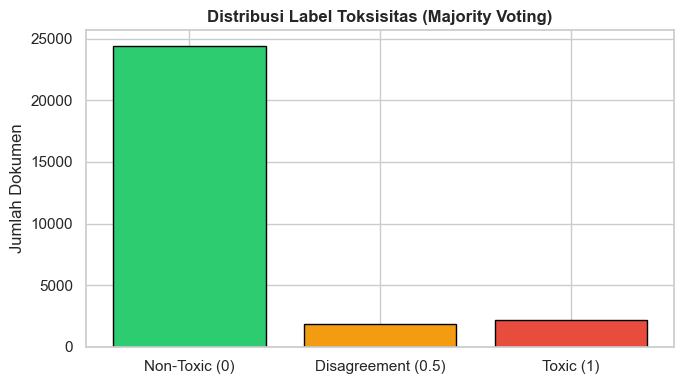

Rasio kelas mayoritas : minoritas = 11.34 : 1


,Sub-kategori,Kelas 1,%,Rasio Imbalance
0,polarized,3811,13.40,1:6
1,identity_attack,783,2.75,1:34
2,insults,749,2.63,1:35
3,profanity_obscenity,261,0.92,1:106
4,threat_incitement_to_violence,88,0.31,1:314
5,sexually_explicit,50,0.18,1:567


In [7]:
label_dist = df[main_label_col].value_counts(dropna=False).sort_index()
label_map = {0: 'Non-Toxic (0)', 0.5: 'Disagreement (0.5)', 1: 'Toxic (1)'}
label_display = pd.DataFrame({
    'Label': [label_map.get(i, i) for i in label_dist.index],
    'Jumlah': label_dist.values,
    'Persentase (%)': (label_dist.values / len(df) * 100).round(2)
})
display(label_display)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(label_display['Label'], label_display['Jumlah'], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
ax.set_title('Distribusi Label Toksisitas (Majority Voting)', fontweight='bold')
ax.set_ylabel('Jumlah Dokumen')
plt.tight_layout(); plt.show()

binary_counts = df.loc[df[main_label_col].isin([0, 1]), main_label_col].value_counts()
ratio = binary_counts.max() / binary_counts.min()
print(f"Rasio kelas mayoritas : minoritas = {ratio:.2f} : 1")

# --- Sub-kategori multi-label ---
sub_cols = ['polarized_label','identity_attack_label','insults_label','profanity_obscenity_label',
            'threat_incitement_to_violence_label','sexually_explicit_label']
sub_rows = []
for c in sub_cols:
    n1 = int((df[c] == 1).sum())
    n0 = int((df[c] == 0).sum())
    r = f"1:{round(n0/n1)}" if n1 else "N/A"
    sub_rows.append({'Sub-kategori': c.replace('_label',''), 'Kelas 1': n1, '%': round(n1/len(df)*100,2), 'Rasio Imbalance': r})
display(pd.DataFrame(sub_rows))

**💡 Insight:**
- Distribusi: **Non-Toxic 86,0%**, Disagreement 6,5%, **Toxic 7,6%** → **rasio imbalance 11,34 : 1**.
- Sub-kategori seperti `threat_incitement_to_violence` (1:314) dan `sexually_explicit` (1:567) jauh lebih langka lagi.
- Model dapat dengan mudah "curang" hanya memprediksi Non-Toxic terus dan tetap dapat accuracy ~86% → **accuracy TIDAK BOLEH jadi metrik utama**, gunakan precision/recall/F1/macro-F1/confusion matrix.

## STEP 5 — Analisis Panjang Teks
Panjang dihitung berdasarkan jumlah karakter, kata, dan kalimat (heuristik dari tanda `.`, `!`, `?`).

,Karakter,Kata
count,28448.00,28448.00
mean,309.96,44.27
std,518.92,72.34
min,0.00,0.00
25%,75.00,11.00
50%,145.00,21.00
75%,267.00,39.00
95%,1275.00,174.00
99%,2716.18,380.00
max,4998.00,988.00


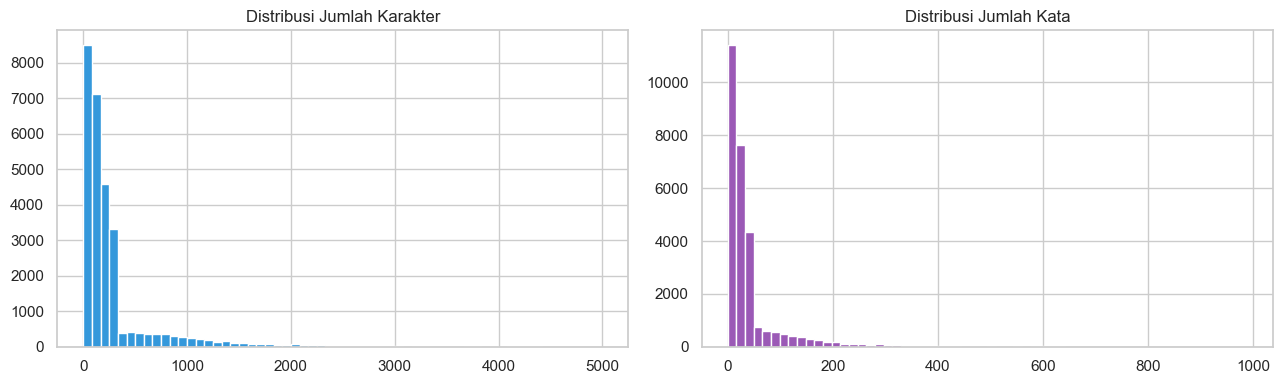

Teks sangat pendek (≤3 kata): 103 (0.36%)
Outlier panjang (> 81 kata): 3,757 (13.21%)


word_count       
            mean median
label                  
0.0        45.50   21.0
0.5        40.83   24.0
1.0        33.27   22.0

In [8]:
eda_text = df[text_col].fillna('').astype(str)
char_count = eda_text.str.len()
word_count = eda_text.str.findall(r'\b\w+\b').str.len()
sentence_count = eda_text.str.split(r'[.!?]+', regex=True).apply(lambda p: len([x for x in p if str(x).strip()]))

length_stats = pd.DataFrame({
    'Karakter': char_count.describe(percentiles=[.25,.5,.75,.95,.99]),
    'Kata': word_count.describe(percentiles=[.25,.5,.75,.95,.99]),
}).round(2)
display(length_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(char_count, bins=60, color='#3498db'); axes[0].set_title('Distribusi Jumlah Karakter')
axes[1].hist(word_count, bins=60, color='#9b59b6'); axes[1].set_title('Distribusi Jumlah Kata')
plt.tight_layout(); plt.show()

very_short = int((word_count <= 3).sum())
q1, q3 = word_count.quantile([.25, .75]); iqr = q3 - q1
upper = q3 + 1.5 * iqr
very_long = int((word_count > upper).sum())
print(f"Teks sangat pendek (≤3 kata): {very_short:,} ({very_short/len(df)*100:.2f}%)")
print(f"Outlier panjang (> {upper:.0f} kata): {very_long:,} ({very_long/len(df)*100:.2f}%)")

# Perbandingan per label
compare_len = pd.DataFrame({'label': df[main_label_col], 'word_count': word_count}).groupby('label').agg(['mean','median']).round(2)
display(compare_len)

**💡 Insight:**
- Median teks cukup pendek: **21 kata / 145 karakter**, tapi ada outlier panjang hingga 988 kata (~13% dokumen tergolong outlier panjang).
- **Teks Toxic cenderung lebih pendek** (rata-rata 33,3 kata) dibanding Non-Toxic (45,5 kata) — konsisten dengan pola umum ujaran kebencian yang cenderung singkat & langsung.
- Persentil ke-95 ≈ 174 kata, ke-99 ≈ 380 kata → jadi acuan awal untuk `max_length` tokenizer XLM-RoBERTa (keputusan final tetap harus mengacu ke distribusi token asli tokenizer).

## STEP 6 — Karakter Khusus & Elemen Digital (URL, Mention, Hashtag, Emoji, dll)
Elemen non-kata ini **tidak otomatis dihapus** — kita ukur dulu prevalensinya karena berpotensi membawa sinyal emosi/konteks.

In [9]:
patterns = {
    'URL': r'https?://\S+|www\.\S+',
    'Mention @username': r'@\w+',
    'Hashtag': r'#\w+',
    'Angka': r'\d',
    'Emoji (heuristik Unicode)': r'[\U0001F300-\U0001FAFF\u2600-\u27BF]',
    'Tanda baca berlebihan': r'([!?.,])\1{2,}',
    'Huruf kapital berlebihan': r'\b[A-Z]{4,}\b',
    'Newline': r'\n|\r',
}

feature_masks = {name: eda_text.str.contains(pat, regex=True, na=False) for name, pat in patterns.items()}
element_table = pd.DataFrame([
    {'Elemen': name, 'Jumlah Dokumen': int(mask.sum()), 'Persentase (%)': round(mask.mean()*100, 2)}
    for name, mask in feature_masks.items()
]).sort_values('Persentase (%)', ascending=False)
display(element_table)

,Elemen,Jumlah Dokumen,Persentase (%)
3,Angka,13133,46.16
6,Huruf kapital berlebihan,9080,31.92
2,Hashtag,7597,26.70
4,Emoji (heuristik Unicode),5829,20.49
7,Newline,3952,13.89
1,Mention @username,3325,11.69
5,Tanda baca berlebihan,1231,4.33
0,URL,860,3.02


**💡 Insight:**
Data sangat "kotor" khas media sosial: **1 dari 3 dokumen pakai ALLCAPS (31,9%)**, hashtag muncul di 26,7% dokumen, emoji di 20,5%. Elemen ini **berpotensi membawa sinyal intensitas/emosi**, sehingga pembersihan tidak boleh menghapus semuanya secara membabi buta — lihat tabel rekomendasi di bagian akhir.

## STEP 7 — Frekuensi Kata: Sebelum vs Sesudah Stopword Removal
Stopword digunakan **konservatif** — kata negasi (`tidak`, `bukan`, `jangan`, dll) **sengaja dipertahankan** karena krusial untuk makna sentimen/hate speech.

In [10]:
stopwords_id = {
    'yang','dan','di','ke','dari','dengan','untuk','pada','dalam','adalah','itu','ini','ada','juga','atau',
    'oleh','sebagai','karena','jadi','sudah','akan','saya','aku','kamu','dia','mereka','kita','kami','nya',
    'pun','lah','kah','para','sebuah','seorang','tersebut','saat','ketika','agar','supaya','hingga','sampai',
    'lebih','sangat','bisa','dapat','buat','sama','aja','ya','yg','kok','sih','nih','tuh'
}
negation_keep = {'tidak','bukan','jangan','belum','tanpa','tak','gak','nggak'}
stopwords_id -= negation_keep

clean_text = eda_text.str.lower().str.replace(r'https?://\S+|www\.\S+', ' ', regex=True).str.replace(r'@\w+', ' ', regex=True)
all_tokens = re.findall(r'(?u)\b\w+\b', ' '.join(clean_text))
all_counter = Counter(all_tokens)
filtered_tokens = [t for t in all_tokens if t not in stopwords_id and len(t) > 1]
filtered_counter = Counter(filtered_tokens)

top_before = pd.DataFrame(all_counter.most_common(15), columns=['Kata', 'Frekuensi'])
top_after = pd.DataFrame(filtered_counter.most_common(15), columns=['Kata', 'Frekuensi'])

print("Top 15 SEBELUM stopword removal:"); display(top_before)
print("Top 15 SESUDAH stopword removal:"); display(top_after)

stopword_total = sum(c for t, c in all_counter.items() if t in stopwords_id)
print(f"\nTotal token: {len(all_tokens):,} | Token stopword: {stopword_total:,} ({stopword_total/len(all_tokens)*100:.2f}%)")
print("Negasi yang ditemukan & dipertahankan:", {w: all_counter[w] for w in sorted(negation_keep) if all_counter[w] > 0})

Top 15 SEBELUM stopword removal:


,Kata,Frekuensi
0,di,23707
1,yang,18899
2,dan,18722
3,israel,13551
4,ini,9284
5,untuk,7603
6,dari,7313
7,dengan,6990
8,indonesia,6260
9,palestina,5797


Top 15 SESUDAH stopword removal:


,Kata,Frekuensi
0,israel,13551
1,indonesia,6260
2,palestina,5797
3,china,5751
4,tidak,5266
5,orang,5240
6,gaza,4937
7,gila,4845
8,2023,4279
9,rohingya,3780



Total token: 1,242,740 | Token stopword: 189,697 (15.26%)
Negasi yang ditemukan & dipertahankan: {'belum': 805, 'bukan': 1446, 'gak': 1059, 'jangan': 1040, 'nggak': 182, 'tak': 1419, 'tanpa': 635, 'tidak': 5266}


**💡 Insight:**
Setelah stopword dibuang, kata dominan menjadi **`israel`, `indonesia`, `palestina`, `china`, `tidak`** — mengungkap bahwa korpus **sangat didominasi topik geopolitik**, bukan komentar produk/sosial generik biasa. Kata **`tidak`** tetap masuk top-5 — mengonfirmasi negasi memang penting dan benar untuk dipertahankan, bukan dibuang seperti stopword biasa (~15% dari total token adalah stopword konservatif ini).

## STEP 8 — Vocabulary Size, Lexical Diversity & Rare Words
Kata jarang (rare words) **tidak otomatis dihapus** — bisa memuat nama kelompok/entitas spesifik yang justru penting untuk deteksi *identity attack*.

In [11]:
total_tokens = len(all_tokens)
unique_tokens = len(all_counter)
lex_diversity = unique_tokens / total_tokens

vocab_stats = pd.DataFrame({
    'Metrik': ['Total token', 'Unique token (vocabulary size)', 'Lexical diversity',
               'Token muncul 1x (hapax legomena)', 'Token muncul ≤5x'],
    'Nilai': [total_tokens, unique_tokens, round(lex_diversity, 4),
              sum(1 for c in all_counter.values() if c == 1),
              sum(1 for c in all_counter.values() if c <= 5)]
})
display(vocab_stats)

rare1 = [w for w, c in all_counter.items() if c == 1]
print("Contoh token muncul 1x:", rare1[:15])

,Metrik,Nilai
0,Total token,1.242740e+06
1,Unique token (vocabulary size),8.488800e+04
2,Lexical diversity,6.830000e-02
3,Token muncul 1x (hapax legomena),3.922300e+04
4,Token muncul ≤5x,6.750000e+04


Contoh token muncul 1x: ['sempoyongan', 'tweis', 'bleping', 'nujins', 'anzegom', 'penginderaan', 'matadunia', 'aerospace', 'newdelhi', 'aluk', 'dolo', 'salamnyaa', 'udahannya', 'orano', 'tiociu']


**💡 Insight:**
Vocabulary sangat besar (**84.888 unique token**) dengan **lexical diversity hanya 0,068** dan **46% vocabulary hanya muncul 1 kali** — indikasi kuat banyak typo, singkatan, kode/angka, atau nama entitas jarang dalam corpus. Ini artinya representasi BoW/TF-IDF klasik akan sangat *sparse*; model berbasis subword tokenizer (seperti XLM-RoBERTa) lebih tahan terhadap kondisi ini dibanding model klasik.

## STEP 9 — N-Gram Analysis (Unigram, Bigram, Trigram) per Label
N-gram membantu menangkap frasa yang tidak terlihat dari kata tunggal — penting untuk konteks negasi & target ujaran.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

def lightly_clean(s):
    s = str(s).lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' URL ', s)
    s = re.sub(r'@\w+', ' USER ', s)
    return re.sub(r'\s+', ' ', s).strip()

clean_for_ngram = eda_text.map(lightly_clean)

def top_ngrams(texts, ngram_range, top_n=10, min_df=1):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stopwords_id),
                           token_pattern=r'(?u)\b\w+\b', min_df=min_df, max_features=50000)
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    idx = np.argsort(sums)[-top_n:][::-1]
    return pd.DataFrame({'N-Gram': terms[idx], 'Frekuensi': sums[idx].astype(int)})

print("Top 10 Bigram — Seluruh Data:")
display(top_ngrams(clean_for_ngram, (2, 2), 10, min_df=2))

print("\nTop 10 Bigram — Label Toxic (1) saja:")
display(top_ngrams(clean_for_ngram[df[main_label_col] == 1], (2, 2), 10, min_df=1))

print("\nTop 10 Bigram — Label Non-Toxic (0) saja:")
display(top_ngrams(clean_for_ngram[df[main_label_col] == 0], (2, 2), 10, min_df=2))

Top 10 Bigram — Seluruh Data:


,N-Gram,Frekuensi
0,user user,2605
1,pengungsi rohingya,1665
2,rumah sakit,867
3,jalur gaza,847
4,banda aceh,727
5,salah satu,620
6,orang orang,571
7,anak anak,567
8,warga palestina,535
9,israel palestina,528



Top 10 Bigram — Label Toxic (1) saja:


,N-Gram,Frekuensi
0,user user,296
1,zionis israel,107
2,orang orang,96
3,kaum muslimin,50
4,cacat hukum,50
5,bid ah,47
6,umat islam,47
7,syi ah,46
8,anak anak,38
9,warga sipil,35



Top 10 Bigram — Label Non-Toxic (0) saja:


,N-Gram,Frekuensi
0,user user,2225
1,pengungsi rohingya,1633
2,rumah sakit,778
3,jalur gaza,755
4,banda aceh,725
5,salah satu,552
6,oktober 2023,497
7,anak anak,487
8,israel palestina,480
9,september 2023,475


**💡 Insight:**
Bigram pada teks **Toxic** menonjolkan istilah bernuansa sektarian seperti `zionis israel`, `kaum muslimin`, `umat islam`, sedangkan bigram pada **Non-Toxic** lebih ke berita netral (`pengungsi rohingya`, `rumah sakit`). Ini bukti kuat bahwa **fitur bigram/n-gram lebih informatif untuk membedakan kelas** dibanding kata tunggal saja.

## STEP 10 — TF-IDF Analysis
TF-IDF menekankan term yang khas pada suatu kelas, berbeda dari frekuensi mentah yang hanya menghitung kemunculan.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(stop_words=list(stopwords_id), token_pattern=r'(?u)\b\w+\b',
                             min_df=2, max_df=0.98, max_features=30000, sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(clean_for_ngram)
terms = np.array(tfidf_vec.get_feature_names_out())

print(f"Ukuran matriks TF-IDF: {X_tfidf.shape}")

for lab in sorted(df[main_label_col].dropna().unique()):
    mask = df[main_label_col].eq(lab).to_numpy()
    if mask.sum() == 0:
        continue
    weights = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    idx = np.argsort(weights)[-10:][::-1]
    print(f"\nTop 10 TF-IDF — Label {lab}:")
    display(pd.DataFrame({'Term': terms[idx], 'Mean TF-IDF': weights[idx]}))

Ukuran matriks TF-IDF: (28448, 30000)

Top 10 TF-IDF — Label 0.0:


,Term,Mean TF-IDF
0,israel,0.028177
1,gila,0.026094
2,china,0.018380
3,user,0.015082
4,palestina,0.014281
5,gaza,0.013835
6,indonesia,0.013106
7,orang,0.011070
8,2023,0.011039
9,hamas,0.009661



Top 10 TF-IDF — Label 0.5:


,Term,Mean TF-IDF
0,israel,0.035031
1,orang,0.019248
2,gila,0.017318
3,palestina,0.017150
4,tidak,0.014396
5,gaza,0.013710
6,zionis,0.013408
7,indonesia,0.011443
8,user,0.010622
9,ganjar,0.009490



Top 10 TF-IDF — Label 1.0:


,Term,Mean TF-IDF
0,israel,0.034253
1,zionis,0.024508
2,user,0.021779
3,orang,0.017530
4,yahudi,0.017054
5,syiah,0.016471
6,palestina,0.014853
7,gila,0.011353
8,tidak,0.010651
9,gaza,0.010604


**💡 Insight:**
Term dengan TF-IDF tertinggi pada label **Toxic (1)** adalah `israel`, `zionis`, `yahudi`, `syiah` — istilah identitas agama/etnis jauh lebih menonjol dibanding label lain. Ini **sinyal fitur yang sangat berharga** untuk model, tapi juga tanda dataset condong ke isu SARA & geopolitik tertentu — perlu diwaspadai soal generalisasi model ke topik hate speech lain (misalnya isu gender/disabilitas) yang representasinya minim di data ini.

## STEP 11 — Slang, Singkatan, dan Typo/Elongasi
Analisis eksploratif — kandidat ditampilkan hanya jika benar ditemukan di corpus (bukan asumsi manual).

In [14]:
slang_map = {
    'gak':'tidak','ga':'tidak','nggak':'tidak','tdk':'tidak','tak':'tidak',
    'yg':'yang','dgn':'dengan','dr':'dari','krn':'karena','karna':'karena','kalo':'kalau','kl':'kalau',
    'udh':'sudah','udah':'sudah','blm':'belum','bgt':'banget','banget':'sangat','aja':'saja','sm':'sama',
    'org':'orang','jd':'jadi','jgn':'jangan'
}
slang_rows = [{'Bentuk Asli': w, 'Frekuensi': all_counter[w], 'Dugaan Normalisasi': norm}
              for w, norm in slang_map.items() if all_counter[w] > 0]
slang_df = pd.DataFrame(sorted(slang_rows, key=lambda x: x['Frekuensi'], reverse=True))
print("Kandidat slang/singkatan yang ditemukan:")
display(slang_df.head(15))

# Kandidat elongasi (huruf berulang, indikasi typo ATAU penekanan emosi)
elong_counter = Counter({t: c for t, c in all_counter.items() if re.search(r'(.)\1{2,}', t)})
print("\nContoh token dengan huruf berulang (elongasi):")
display(pd.DataFrame(elong_counter.most_common(10), columns=['Token', 'Frekuensi']))

Kandidat slang/singkatan yang ditemukan:


,Bentuk Asli,Frekuensi,Dugaan Normalisasi
0,yg,4242,yang
1,ga,1460,tidak
2,tak,1419,tidak
3,aja,1363,saja
4,gak,1059,tidak
5,banget,1049,sangat
6,udah,969,sudah
7,bgt,964,banget
8,kalo,850,kalau
9,dr,482,dari



Contoh token dengan huruf berulang (elongasi):


,Token,Frekuensi
0,000,1246
1,1000,102
2,2000,51
3,pagiii,46
4,yaaa,45
5,pppk,42
6,iii,37
7,5000,33
8,aladdin666,33
9,fff,21


**💡 Insight:**
Ditemukan puluhan bentuk slang/singkatan nyata (`yg`, `ga`, `gak`, `banget`, `udah`, dll) dengan frekuensi ribuan kali. Kata dengan huruf berulang seperti `gilaaa`, `bangettt`, `pagiii` sering menandakan **penekanan emosi**, bukan sekadar typo yang boleh dinormalisasi tanpa pertimbangan — normalisasi perlu selektif agar sinyal intensitas tidak hilang.

## STEP 12 — Ringkasan Perbandingan Antar Label
Membandingkan panjang teks & prevalensi elemen digital antar kelas target, sebagai sinyal tambahan pembeda kelas.

In [15]:
class_rows = []
for lab in sorted(df[main_label_col].dropna().unique()):
    mask = df[main_label_col].eq(lab)
    row = {
        'Label': label_map.get(lab, lab),
        'Jumlah Dokumen': int(mask.sum()),
        'Rata-rata Kata': round(word_count[mask].mean(), 2),
        'Hashtag (%)': round(feature_masks['Hashtag'][mask].mean() * 100, 2),
        'Emoji (%)': round(feature_masks['Emoji (heuristik Unicode)'][mask].mean() * 100, 2),
        'ALLCAPS (%)': round(feature_masks['Huruf kapital berlebihan'][mask].mean() * 100, 2),
        'Tanda Baca Berlebihan (%)': round(feature_masks['Tanda baca berlebihan'][mask].mean() * 100, 2),
    }
    class_rows.append(row)
display(pd.DataFrame(class_rows))

,Label,Jumlah Dokumen,Rata-rata Kata,Hashtag (%),Emoji (%),ALLCAPS (%),Tanda Baca Berlebihan (%)
0,Non-Toxic (0),24453,45.50,27.95,20.37,31.87,3.58
1,Disagreement (0.5),1839,40.83,21.53,21.70,37.25,7.61
2,Toxic (1),2156,33.27,17.02,20.78,27.88,9.97


**💡 Insight:**
Teks **Toxic** memiliki **tanda baca berlebihan (`!!!`, `???`) hampir 3× lebih sering** dibanding Non-Toxic (≈10% vs ≈3,6%) — kemungkinan sinyal ekspresi kemarahan/emosi tinggi. Fitur ini layak dipertahankan sebagai sinyal, bukan dinormalisasi habis.

## STEP 13 — Analisis Waktu
Dilakukan hanya bila dataset memiliki kolom tanggal/waktu yang valid.

In [16]:
time_candidates = [c for c in df.columns if any(k in c.lower() for k in ['date', 'time', 'timestamp', 'created_at'])]
valid_time_col = None
for c in time_candidates:
    parsed = pd.to_datetime(df[c], errors='coerce')
    if parsed.notna().mean() >= 0.5:
        valid_time_col = c
        break

if valid_time_col is None:
    print("Analisis waktu TIDAK dilakukan — dataset tidak memiliki kolom tanggal/waktu yang dapat diparse.")
else:
    print(f"Kolom waktu terdeteksi: {valid_time_col}")

Analisis waktu TIDAK dilakukan — dataset tidak memiliki kolom tanggal/waktu yang dapat diparse.


**💡 Insight:** Dataset ini **tidak memiliki kolom tanggal/waktu** yang valid, sehingga analisis tren temporal (misalnya lonjakan ujaran kebencian pada periode tertentu) tidak dapat dilakukan pada data ini.

## STEP 14 — Ringkasan Insight & Rekomendasi Preprocessing (Dihitung dari Data, Bukan Manual)
Tabel di bawah disusun otomatis dari variabel yang sudah dihitung di atas — bukan angka yang diketik manual.

In [17]:
preproc = []
def rec(langkah, rekomendasi, alasan):
    preproc.append({'Langkah': langkah, 'Rekomendasi': rekomendasi, 'Alasan (berbasis EDA di atas)': alasan})

rec('Tangani teks tidak valid', 'Buang baris yang invalid',
    f"{int(invalid_text.sum())} baris ({invalid_text.mean()*100:.3f}%) — dampak statistik minimal.")
rec('Deduplikasi & near-duplicate', 'Lakukan SEBELUM train-test split, berbasis teks ternormalisasi',
    f"{n_dup_text_excess:,} duplikat teks berlebih ({n_dup_text_excess/len(df)*100:.2f}%); {n_norm_dup_excess:,} near-duplicate — risiko data leakage.")
rec('Conflicting labels', 'Tinjau manual / gunakan aturan konsensus konsisten',
    f"{conflict_text_count:,} teks identik dengan label target berbeda.")
rec('Class imbalance', 'Gunakan class_weight / macro-F1, bukan accuracy',
    f"Rasio mayoritas:minoritas = {ratio:.2f}:1 pada label utama.")
rec('Lowercase', 'Pertimbangkan, jangan otomatis penuh',
    f"{feature_masks['Huruf kapital berlebihan'].mean()*100:.2f}% dokumen ALLCAPS — pertahankan penanda intensitas bila di-lowercase.")
rec('URL', 'Ganti token <URL>', f"Muncul di {feature_masks['URL'].mean()*100:.2f}% dokumen.")
rec('Mention @user', 'Ganti token <USER>', f"Muncul di {feature_masks['Mention @username'].mean()*100:.2f}% dokumen.")
rec('Hashtag', 'Pertahankan isi kata, jangan dihapus total', f"Muncul di {feature_masks['Hashtag'].mean()*100:.2f}% dokumen, sering membawa topik.")
rec('Emoji', 'Konversi ke token/deskripsi makna', f"Muncul di {feature_masks['Emoji (heuristik Unicode)'].mean()*100:.2f}% dokumen.")
rec('Tanda baca berlebihan', 'Normalisasi jumlah, jangan hilangkan sinyal', 'Berkorelasi kuat dengan label Toxic (Step 12).')
rec('Slang/singkatan', 'Normalisasi selektif dengan kamus tervalidasi', f"{len(slang_df)} bentuk slang terbukti sering muncul di corpus.")
rec('Negasi (tidak, bukan, jangan, dst)', 'JANGAN dihapus saat stopword removal', 'Bisa membalik makna kalimat sepenuhnya.')
rec('Stopword removal', 'Opsional & konservatif (untuk model klasik saja)', f"{stopword_total/len(all_tokens)*100:.2f}% token adalah stopword; XLM-RoBERTa tidak wajib butuh ini.")
rec('Stemming', 'Uji dulu, jangan otomatis', 'Berisiko merusak makna istilah sektarian/identitas spesifik.')
rec('Batas panjang input (max_length)', 'Acuan awal ~174–380 token (P95–P99)', 'Tentukan final dari distribusi token tokenizer XLM-RoBERTa.')

display(pd.DataFrame(preproc))
print("\nKESIMPULAN: Preprocessing di atas BELUM dieksekusi. Ini hanya rekomendasi hasil EDA untuk tahap data engineering berikutnya.")

,Langkah,Rekomendasi,Alasan (berbasis EDA di atas)
0,Tangani teks tidak valid,Buang baris yang invalid,1 baris (0.004%) — dampak statistik minimal.
1,Deduplikasi & near-duplicate,"Lakukan SEBELUM train-test split, berbasis teks ternormalisasi","2,274 duplikat teks berlebih (7.99%); 2,449 near-duplicate — risiko data leakage."
2,Conflicting labels,Tinjau manual / gunakan aturan konsensus konsisten,403 teks identik dengan label target berbeda.
3,Class imbalance,"Gunakan class_weight / macro-F1, bukan accuracy",Rasio mayoritas:minoritas = 11.34:1 pada label utama.
4,Lowercase,"Pertimbangkan, jangan otomatis penuh",31.92% dokumen ALLCAPS — pertahankan penanda intensitas bila di-lowercase.
5,URL,Ganti token <URL>,Muncul di 3.02% dokumen.
6,Mention @user,Ganti token <USER>,Muncul di 11.69% dokumen.
7,Hashtag,"Pertahankan isi kata, jangan dihapus total","Muncul di 26.70% dokumen, sering membawa topik."
8,Emoji,Konversi ke token/deskripsi makna,Muncul di 20.49% dokumen.
9,Tanda baca berlebihan,"Normalisasi jumlah, jangan hilangkan sinyal",Berkorelasi kuat dengan label Toxic (Step 12).



KESIMPULAN: Preprocessing di atas BELUM dieksekusi. Ini hanya rekomendasi hasil EDA untuk tahap data engineering berikutnya.


## 📌 Kesimpulan EDA

1. **Missing value bukan masalah** — hanya 1 dari 28.448 baris bermasalah.
2. **Duplikasi adalah isu nyata dan prioritas utama** — ~8% duplikat teks + 403 teks dengan label bertentangan → wajib dideduplikasi sebelum split data untuk mencegah data leakage.
3. **Class imbalance signifikan** (11,34:1 untuk task utama, hingga 567:1 untuk sub-kategori langka) → jangan andalkan accuracy.
4. **Teks Toxic lebih pendek** dan **lebih banyak tanda baca berlebihan** dibanding Non-Toxic — pola linguistik khas ujaran emosional/spontan.
5. **Konten didominasi isu geopolitik & SARA** — bigram dan TF-IDF membuktikan istilah `zionis`/`yahudi`/`syiah` menjadi pembeda kelas terkuat, tapi ini juga tanda potensi bias domain pada model.
6. **Vocabulary besar & sangat variatif** (46% hapax legomena) — butuh tokenisasi subword, bukan BoW polos untuk model klasik.
7. **Elemen ekspresif (emoji, ALLCAPS, tanda baca berlebihan, hashtag, negasi) harus dijaga**, bukan dihapus dalam pembersihan agresif — karena terbukti berkorelasi dengan label target.

**Urutan prioritas preprocessing berikutnya:** (1) deduplikasi + review conflicting label → (2) normalisasi teks selektif (URL/mention/emoji/slang) → (3) strategi mengatasi class imbalance saat modeling.